R2: 0.6947916640638987


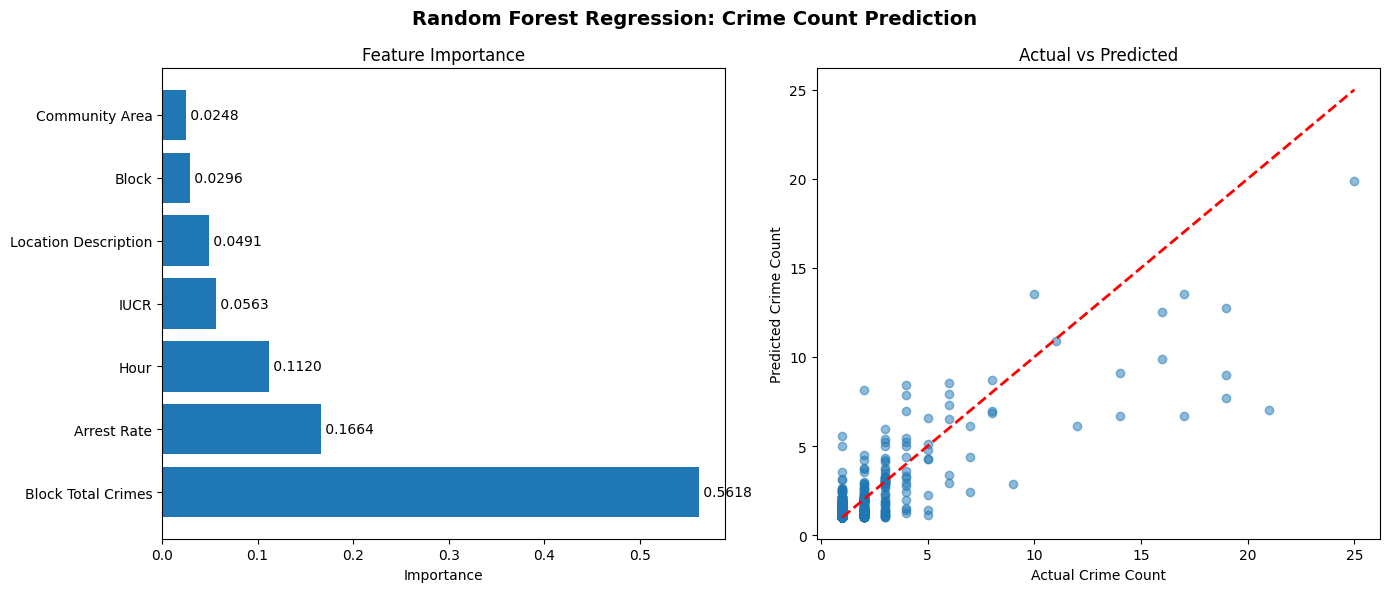

  Predicted Crime Count: 1.1801281021829844 incidents

Model: Random Forest Regressor

Key Findings (Influencing Factors):
  1. Block Total Crimes: 56.2%
  2. Arrest Rate: 16.6%
  3. Hour: 11.2%
  4. IUCR: 5.6%



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

df = pd.read_csv(r'C:\CSE163\crime-prediction\Crimes_-_2001_to_Present.csv', nrows=20000)
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
df['Hour'] = df['Date'].dt.hour

df['Latitude'] = df['Latitude'].fillna(df['Latitude'].median())
df['Longitude'] = df['Longitude'].fillna(df['Longitude'].median())

for col in ['Location Description', 'Primary Type']:
    df[col] = df[col].fillna(df[col].mode()[0])

df_clean = df.dropna(subset=['Block', 'Hour', 'Arrest', 'Year', 'Domestic', 'Community Area', 'IUCR', 'Location Description'])

df_clean['Arrest'] = df_clean['Arrest'].astype(int)
df_clean['Domestic'] = df_clean['Domestic'].astype(int)

crime_counts = df_clean.groupby(['Block', 'Hour']).size().reset_index(name='crime_count')

block_total_crimes = df_clean.groupby('Block').size().reset_index(name='block_total_crimes')
crime_counts = crime_counts.merge(block_total_crimes, on='Block', how='left')

arrest_rates = df_clean.groupby(['Block', 'Hour'])['Arrest'].mean().reset_index(name='arrest_rate')
crime_counts = crime_counts.merge(arrest_rates, on=['Block', 'Hour'], how='left')

feature_agg = df_clean.groupby(['Block', 'Hour']).agg({
    'Community Area': 'first',
    'IUCR': 'first',
    'Location Description': 'first'
}).reset_index()

crime_counts = crime_counts.merge(feature_agg, on=['Block', 'Hour'], how='left')

le_block = LabelEncoder()
crime_counts['Block_encoded'] = le_block.fit_transform(crime_counts['Block'])

le_community = LabelEncoder()
crime_counts['Community Area_encoded'] = le_community.fit_transform(crime_counts['Community Area'].astype(str))

le_iucr = LabelEncoder()
crime_counts['IUCR_encoded'] = le_iucr.fit_transform(crime_counts['IUCR'])

le_location = LabelEncoder()
crime_counts['Location Description_encoded'] = le_location.fit_transform(crime_counts['Location Description'])

features = ['Block_encoded', 'Hour', 'arrest_rate', 'block_total_crimes',
            'Community Area_encoded', 'IUCR_encoded', 'Location Description_encoded']
X = crime_counts[features]
y = crime_counts['crime_count']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print("R2:",test_r2)

impo_factors = pd.DataFrame({
    'feature': ['Block', 'Hour', 'Arrest Rate', 'Block Total Crimes','Community Area', 'IUCR', 'Location Description'],
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Random Forest Regression: Crime Count Prediction', fontsize=14, fontweight='bold')

ax1 = axes[0]
ax1.barh(impo_factors['feature'], impo_factors['importance'])
ax1.set_xlabel('Importance')
ax1.set_title('Feature Importance')
for i, j in enumerate(impo_factors['importance']):
    ax1.text(j, i, f' {j:.4f}', va='center')

ax2 = axes[1]
ax2.scatter(y_test, y_pred_test, alpha=0.5)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_xlabel('Actual Crime Count')
ax2.set_ylabel('Predicted Crime Count')
ax2.set_title('Actual vs Predicted')

plt.tight_layout()
plt.savefig('rf_crime_prediction.png', dpi=300, bbox_inches='tight')
plt.show()

sample_block = crime_counts['Block'].iloc[0]
sample_hour = 12
sample_arrest_rate = 0.5
sample_total_crimes = block_total_crimes[block_total_crimes['Block'] == sample_block]['block_total_crimes'].values[0]

sample_community = str(crime_counts[crime_counts['Block'] == sample_block]['Community Area'].iloc[0])
sample_iucr = crime_counts[crime_counts['Block'] == sample_block]['IUCR'].iloc[0]
sample_location = crime_counts[crime_counts['Block'] == sample_block]['Location Description'].iloc[0]

sample_X = pd.DataFrame({
    'Block_encoded': [le_block.transform([sample_block])[0]],
    'Hour': [sample_hour],
    'arrest_rate': [sample_arrest_rate],
    'block_total_crimes': [sample_total_crimes],
    'Community Area_encoded': [le_community.transform([sample_community])[0]],
    'IUCR_encoded': [le_iucr.transform([sample_iucr])[0]],
    'Location Description_encoded': [le_location.transform([sample_location])[0]]
})

prediction = rf_model.predict(sample_X)[0]

print(f"  Predicted Crime Count: {prediction} incidents")

print(f"""
Model: Random Forest Regressor

Key Findings (Influencing Factors):
  1. {impo_factors.iloc[0]['feature']}: {impo_factors.iloc[0]['importance']*100:.1f}%
  2. {impo_factors.iloc[1]['feature']}: {impo_factors.iloc[1]['importance']*100:.1f}%
  3. {impo_factors.iloc[2]['feature']}: {impo_factors.iloc[2]['importance']*100:.1f}%
  4. {impo_factors.iloc[3]['feature']}: {impo_factors.iloc[3]['importance']*100:.1f}%
""")

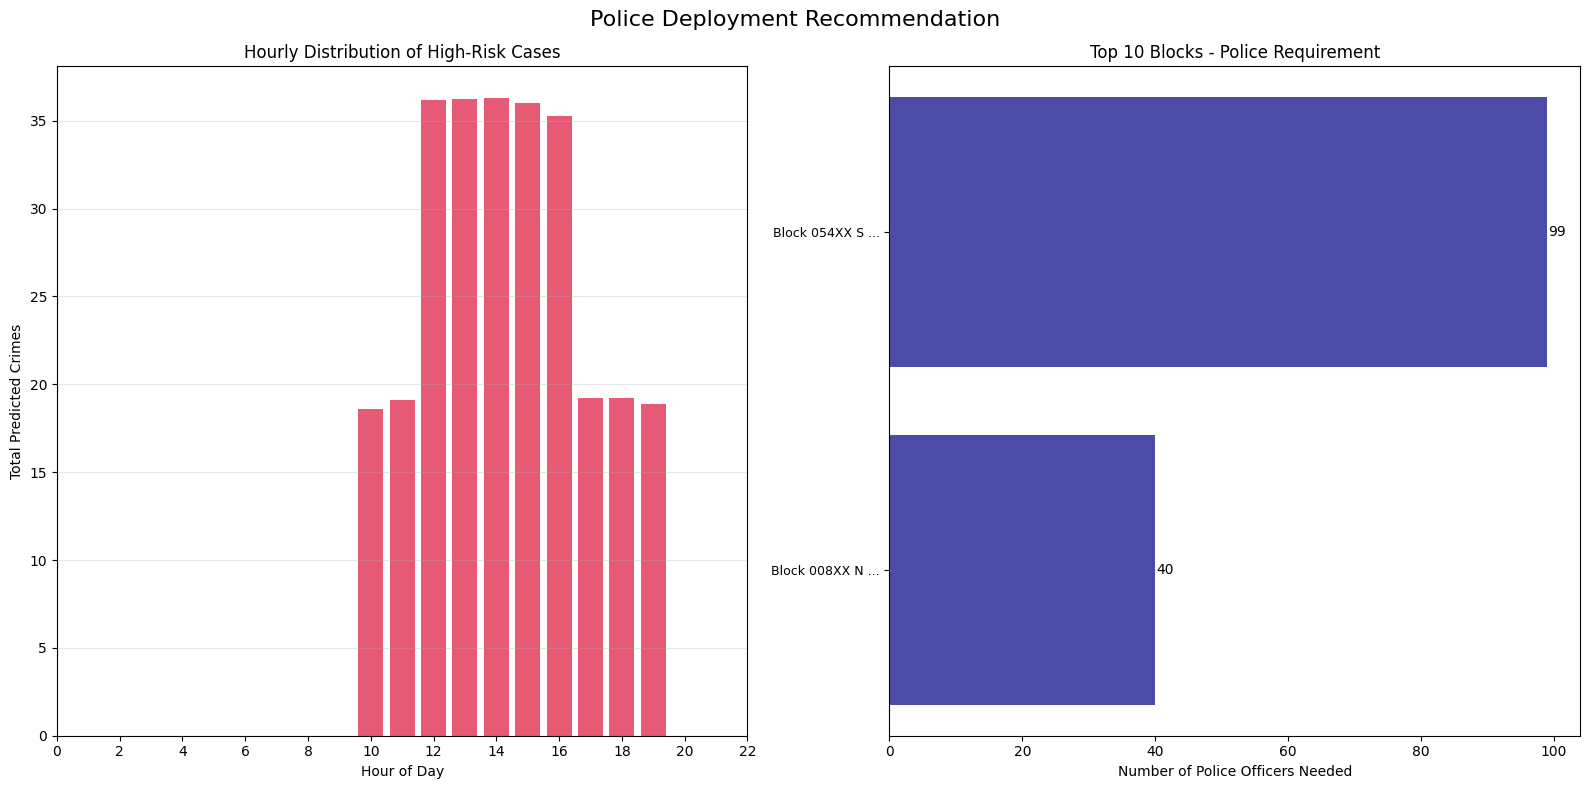

Deployment Summary:
   Total predicted crimes in high-risk areas: 275.1
   Total police officers recommended: 138
   Highest risk hour: 14:00 (Total crimes: 36.3)
   Highest risk block: 054XX S WENTWOR... (Police needed: 99)


In [4]:
top_30_blocks = crime_counts.groupby('Block')['crime_count'].sum().nlargest(30).index.tolist()#predict the top30 blocks
deployment_predictions = []
for block in top_30_blocks:
    block_encoded = le_block.transform([block])[0]
    block_total = crime_counts[crime_counts['Block'] == block]['block_total_crimes'].iloc[0]
    arrest_rate = crime_counts[crime_counts['Block'] == block]['arrest_rate'].mean()
    community = str(crime_counts[crime_counts['Block'] == block]['Community Area'].iloc[0])
    iucr = crime_counts[crime_counts['Block'] == block]['IUCR'].iloc[0]
    location = crime_counts[crime_counts['Block'] == block]['Location Description'].iloc[0]
    
    community_encoded = le_community.transform([community])[0]
    iucr_encoded = le_iucr.transform([iucr])[0]
    location_encoded = le_location.transform([location])[0]
    for hour in range(24):
        pred_data = pd.DataFrame({'Block_encoded': [block_encoded],'Hour': [hour],'arrest_rate': [arrest_rate],
            'block_total_crimes': [block_total],'Community Area_encoded': [community_encoded],'IUCR_encoded': [iucr_encoded],
            'Location Description_encoded': [location_encoded]
        })
        pred_crime = max(0, rf_model.predict(pred_data)[0])
        deployment_predictions.append({
            'Block': block,'Hour': hour,'Predicted_Crimes': pred_crime,'Location_Type': location})
deployment_df = pd.DataFrame(deployment_predictions)# Generate deployment recommendations
high_risk_cases = deployment_df.nlargest(15, 'Predicted_Crimes')#toop15 risky
for rank, (_, row) in enumerate(high_risk_cases.iterrows(), 1):
    police_needed = int(np.ceil(row['Predicted_Crimes'] / 2))#1 police per two crimes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Police Deployment Recommendation', fontsize=16)

# Hourly risk distribution
hourly_risk = high_risk_cases.groupby('Hour')['Predicted_Crimes'].sum()
ax1.bar(hourly_risk.index, hourly_risk.values, color='crimson', alpha=0.7)
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Total Predicted Crimes')
ax1.set_title('Hourly Distribution of High-Risk Cases')
ax1.set_xticks(range(0, 24, 2))
ax1.grid(axis='y', alpha=0.3)

block_police = high_risk_cases.groupby('Block').agg({
    'Predicted_Crimes': 'sum'
}).reset_index()
block_police['Police_Needed'] = np.ceil(block_police['Predicted_Crimes'] / 2).astype(int)
block_police = block_police.nlargest(10, 'Police_Needed')# Top 10 blocks police requirement

ax2.barh(range(len(block_police)), block_police['Police_Needed'], color='navy', alpha=0.7)
ax2.set_yticks(range(len(block_police)))
ax2.set_yticklabels([f"Block {b[:8]}..." for b in block_police['Block']], fontsize=9)
ax2.set_xlabel('Number of Police Officers Needed')
ax2.set_title('Top 10 Blocks - Police Requirement')
ax2.invert_yaxis()
for i, v in enumerate(block_police['Police_Needed']):
    ax2.text(v + 0.1, i, str(v), va='center')

plt.tight_layout()
plt.savefig('police_deployment_recommendation.png', dpi=300, bbox_inches='tight')
plt.show()

# Deployment summary
total_predicted = high_risk_cases['Predicted_Crimes'].sum()
total_police = int(np.ceil(total_predicted / 2))
print(f"Deployment Summary:")
print(f"   Total predicted crimes in high-risk areas: {total_predicted:.1f}")
print(f"   Total police officers recommended: {total_police}")
print(f"   Highest risk hour: {hourly_risk.idxmax()}:00 (Total crimes: {hourly_risk.max():.1f})")
print(f"   Highest risk block: {block_police.iloc[0]['Block'][:15]}... (Police needed: {block_police.iloc[0]['Police_Needed']})")